# Simplified implementation of V2 Model

This notebook implements an alternative methodology for energy price forecasting using zero-shot topic classification of news articles. The approach leverages transformer-based models to automatically classify news headlines into energy-relevant categories without requiring task-specific training data.

## Methodology Overview

Traditional energy forecasting models typically rely on structured data such as historical prices, weather patterns, and generation capacity. This implementation explores whether incorporating unstructured text data (news articles) can improve forecasting performance by capturing market sentiment and emerging trends that may not be immediately reflected in structured data.

The methodology follows a three-stage process:
1. **News Collection**: Gather energy-related news from English and German sources
2. **Zero-Shot Classification**: Automatically categorize articles into energy price drivers using pre-trained transformer models
3. **Time-Decay Aggregation**: Weight news impact using exponential decay over a rolling window
4. **Forecasting**: Train predictive models (Linear Regression and XGBoost) with expanding window validation

---
## Importing

In [1]:
# Core libraries
import pandas as pd
import numpy as np
from datetime import datetime, timedelta
import json
from tqdm import tqdm

# API libraries
from newsapi import NewsApiClient
import requests
from deep_translator import GoogleTranslator

# NLP libraries
from sentence_transformers import SentenceTransformer
from transformers import DebertaTokenizer, DebertaForSequenceClassification
from transformers import pipeline

# ML Libraries
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LinearRegression

# Other libraries
import os
from dotenv import load_dotenv
import matplotlib.pyplot as plt

/Users/nicolas/Desktop/Repos/zhaw_mle/.conda/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


---

# News Data Collection

We collect news articles from multiple sources to capture comprehensive coverage of energy-related events and developments. The data collection process uses the NewsAPI.org service, which aggregates articles from major news outlets.

## Data Collection Strategy

The function `fetch_news_data()` retrieves articles from specified sources using keyword-based queries. Articles are fetched in weekly increments to comply with API rate limits, then combined and deduplicated. The function handles both English and German sources, with German articles being translated to English for subsequent analysis.

This approach aligns with methodologies in computational finance research that use news sentiment analysis for price prediction. By collecting articles from multiple languages and sources, we aim to capture a more complete picture of energy market sentiment than would be possible with single-language or single-source data.

In [2]:
def fetch_news_data(start_date: str, end_date: str, language: str, keywords: str, source: str, api_key: str) -> pd.DataFrame:
    """
    Fetch news articles from NewsAPI.org with flexible keywords.
    
    Parameters:
        start_date : Start date in format 'YYYY-MM-DD'
        end_date : End date in format 'YYYY-MM-DD'
        language : Language of the news articles (str)
        keywords : Search keywords (str)
        source : List of sources (str)
        api_key : str
    
    Returns:
        DataFrame with columns: 'publishedAt', 'title', 'source', 'url'
    """
    
    newsapi = NewsApiClient(api_key=api_key)
    
    # Calculate date ranges to fetch in weekly increments (data limits)
    end_date = datetime.strptime(end_date, '%Y-%m-%d')
    start_date = datetime.strptime(start_date, '%Y-%m-%d')
    all_articles = []

    total_days = (end_date - start_date).days
    num_periods = (total_days // 7) + (1 if total_days % 7 > 0 else 0)

    # Loop for fetching data
    for period in range(num_periods):
        
        to_date = end_date - timedelta(days=period * 7)
        from_date = to_date - timedelta(days=7)
        from_str = from_date.strftime('%Y-%m-%d')
        to_str = to_date.strftime('%Y-%m-%d')

        articles_period = newsapi.get_everything(
            q=keywords,
            sources=source,
            language=language,
            sort_by='relevancy',
            from_param=from_str,
            to=to_str,
            page_size=100
        )
        
        all_articles.extend(articles_period['articles'])

    # Conversion to DataFrame
    news_df = pd.DataFrame([
        {
            'publishedAt': article['publishedAt'],
            'title': article.get('title', ''),
            'source': article['source']['name'],
            'description': article.get('description', ''),
        }
        for article in all_articles
    ])

    # Date Conversion, Sorting and Duplicate Removal + Validation Check
    news_df['publishedAt'] = pd.to_datetime(news_df['publishedAt'])
    news_df = news_df.sort_values('publishedAt')
    news_df = news_df.drop_duplicates(subset=['title'], keep='first')

    if news_df.empty:
        print("Warning: No articles fetched!")
        return pd.DataFrame(columns=['publishedAt', 'title', 'source'])
    else:
        print(f"Successfully fetched {len(news_df)} articles")
        return news_df

## Multi-Language News Collection

We collect news from both English and German sources to ensure comprehensive coverage of European energy markets. German sources are particularly important for capturing local market dynamics and policy developments that may affect energy prices in Germany, which serves as a key benchmark market in this study.

In [3]:
# Define our search parameters - 3 month window
end_date = (datetime.now() - timedelta(days=1)).strftime('%Y-%m-%d')
start_date = (datetime.now() - timedelta(days=90)).strftime('%Y-%m-%d')

# German keywords
keywords_de = (
    '"Energie" OR "Strom" OR "Energiewende" OR "Kraftwerk" OR '
    '"Erneuerbare" OR "Stromversorgung" OR "Energieversorgung" OR '
    '"Stromerzeugung" OR "Energieerzeugung"OR "Inflation"'
)
source_de = 'bild, der-tagesspiegel,die-zeit,focus,handelsblatt,spiegel-online,wirtschafts-woche'

# English keywords add AND statements to limit to european news
keywords_en = (
    '"Energy" OR "Electricity" OR "Energy Transition" OR "Power Plant" OR '
    '"Renewable" OR "Electricity Supply" OR "Energy Supply" OR '
    '"Electricity Generation" OR "Energy Generation" OR "Inflation" AND "Europe"'
)

source_en = 'abc-news, associated-press, bbc-news, bloomberg, cnbc, google-news, reuters, the-new-york-times, the-wall-street-journal'

load_dotenv()
NEWS_API_KEY = os.getenv('NEWSAPIORG_KEY')

# Fetch the data
news_df_de = fetch_news_data(start_date, end_date, 'de', keywords_de, source_de, NEWS_API_KEY)
news_df_en = fetch_news_data(start_date, end_date, 'en', keywords_en, source_en, NEWS_API_KEY)

Successfully fetched 1063 articles
Successfully fetched 32 articles


## Translation of German News Articles

Since zero-shot classification models are typically trained on English text and perform best in their native language, we translate German news articles to English before classification. This approach ensures consistent classification quality across both language sources.

Translation is performed using the Google Translate API via the `deep_translator` library. The translation preserves semantic meaning while converting text to a format that the classification model can process effectively. This multilingual approach has been shown to improve coverage in financial forecasting applications.

In [4]:
translator = GoogleTranslator(source='de', target='en')

news_df_de_translated = news_df_de.copy()

news_df_de_translated['title'] = [
    translator.translate(title) if pd.notna(title) and title.strip() != '' else title
    for title in tqdm(news_df_de['title'], desc="Translating titles")
]

news_df_de_translated['description'] = [
    translator.translate(desc) if pd.notna(desc) and desc.strip() != '' else desc
    for desc in tqdm(news_df_de['description'], desc="Translating descriptions")
]

news_df_combined = pd.concat([news_df_en, news_df_de_translated], ignore_index=True)
news_df_combined = news_df_combined.sort_values('publishedAt').reset_index(drop=True)
news_df_combined = news_df_combined.drop_duplicates(subset=['title'], keep='first')

Translating descriptions: 100%|██████████| 1063/1063 [12:43<00:00,  1.39it/s]


---
# Energy Market Data

We collect hourly electricity price and power generation data from the Energy Charts API, which provides comprehensive data for the German/Luxembourg bidding zone (DE-LU). This data serves as both features (power generation) and targets (price) for our forecasting models.

The Energy Charts API provides:
- **Day-ahead spot prices**: Hourly electricity prices in €/MWh
- **Power generation**: Aggregated hourly generation from all production sources

This structured data complements the news-based features by providing concrete measurements of supply and demand fundamentals. The combination of structured market data with unstructured text data follows approaches in financial forecasting research.

In [5]:
def fetch_energy_charts_data(start_date: str, end_date: str, bidding_zone: str = 'DE-LU') -> pd.DataFrame:
    """
    Fetch hourly price and power generation data from Energy Charts API.
    
    Parameters:
    -----------
    start_date : str
        Start date in format 'YYYY-MM-DD'
    end_date : str
        End date in format 'YYYY-MM-DD'
    bidding_zone : str
        Bidding zone code (default: 'DE-LU' for Germany/Luxembourg)
    
    Returns:
    --------
    pd.DataFrame
        DataFrame with datetime index and columns: 'price', 'total_power'
    """
    base_url = "https://api.energy-charts.info"
    
    price_url = f"{base_url}/price"
    price_params = {
        'bzn': bidding_zone,
        'start': start_date,
        'end': end_date
    }
    
    try:
        price_response = requests.get(price_url, params=price_params, timeout=30)
        price_response.raise_for_status()
        price_data = price_response.json()
    except requests.exceptions.RequestException as e:
        raise requests.exceptions.RequestException(f"Error fetching price data: {e}")
    
    power_url = f"{base_url}/total_power"
    power_params = {
        'country': 'de',
        'start': start_date,
        'end': end_date
    }
    
    try:
        power_response = requests.get(power_url, params=power_params, timeout=30)
        power_response.raise_for_status()
        power_data = power_response.json()
    except requests.exceptions.RequestException as e:
        raise requests.exceptions.RequestException(f"Error fetching power data: {e}")
    
    if 'unix_seconds' in price_data and 'price' in price_data:
        price_timestamps = pd.to_datetime(price_data['unix_seconds'], unit='s')
        prices = price_data['price']
        price_df = pd.DataFrame({'price': prices}, index=price_timestamps)
    else:
        raise ValueError("Unexpected price data structure")
    
    if 'unix_seconds' in power_data and 'production_types' in power_data:
        power_timestamps = pd.to_datetime(power_data['unix_seconds'], unit='s')
        
        total_power = np.zeros(len(power_timestamps))
        for production_type in power_data['production_types']:
            try:
                production_values = np.array(production_type['data'])
                total_power += production_values
            except Exception:
                continue
        
        power_df = pd.DataFrame({'total_power': total_power}, index=power_timestamps)
    else:
        raise ValueError("Unexpected power data structure")
    
    energy_df = price_df.join(power_df, how='outer')
    
    return energy_df

start_date = (datetime.now() - timedelta(days=90)).strftime('%Y-%m-%d')
end_date = (datetime.now() - timedelta(days=1)).strftime('%Y-%m-%d')

energy_df = fetch_energy_charts_data(start_date, end_date)
energy_df.head()


,price,total_power
2025-07-30 22:00:00,88.93,119987.0
2025-07-30 22:15:00,NaN,118794.7
2025-07-30 22:30:00,NaN,117465.2
2025-07-30 22:45:00,NaN,116410.4
2025-07-30 23:00:00,82.11,114345.2


---
# Zero-Shot Topic Classification

We employ zero-shot classification to automatically categorize news articles into energy-relevant topics without requiring labeled training data. This approach leverages pre-trained transformer models that can perform classification tasks using only candidate labels and a hypothesis template.

## Model Selection: DeBERTa

We use the DeBERTa-v3-base model fine-tuned for zero-shot classification (MoritzLaurer/deberta-v3-base-zeroshot-v2.0). DeBERTa (Decoding-enhanced BERT with Disentangled Attention) improves upon BERT by using disentangled attention mechanisms and an enhanced mask decoder. The zero-shot variant has been specifically trained to perform classification across diverse domains without task-specific fine-tuning.

The zero-shot approach is particularly valuable for financial and energy market analysis, where labeled training data is often scarce and domain-specific.

## Classification Categories

Each news article is classified into one of the following categories representing key energy price drivers:

In [6]:
candidate_labels = [
    # Energy consumption
    "energy consumption is rising",
    "energy consumption is falling",

    # Energy production / generation availability
    "energy production or generation availability is rising",
    "energy production or generation availability is falling",

    # Commodity prices (gas/coal/oil)
    "commodity prices for natural gas, coal, or oil are rising",
    "commodity prices for natural gas, coal, or oil are falling",

    # Geopolitics
    "geopolitical tensions or supply disruptions are increasing and likely to raise energy prices",
    "geopolitical tensions are easing and likely to lower energy prices",

    # Germany weather impact on power prices
    "Germany weather is bullish for power prices (colder, lower wind/solar, tighter supply)",
    "Germany weather is bearish for power prices (milder, higher wind/solar, looser supply)",

    # Catch-all
    "other (not related to these energy price drivers)"
]

hypothesis_template = "This text indicates that {}."

## Two-Stage Classification Strategy

We employ a two-stage classification approach to balance computational efficiency with classification accuracy:

1. **Stage 1: Title Classification**: All articles are first classified based on their titles alone. This is computationally efficient since titles are typically much shorter than full article descriptions.

2. **Stage 2: Description Re-classification**: Articles classified as "other" (indicating they don't match any energy-related category) are re-classified using their full descriptions. This provides more context and can improve classification accuracy for articles with ambiguous titles.

In [7]:
import torch

# Check for device availability in order: CUDA -> MPS -> CPU
if torch.cuda.is_available():
    device = 0
elif torch.backends.mps.is_available():
    device = "mps"
else:
    device = -1

classifier = pipeline(
    "zero-shot-classification",
    model="MoritzLaurer/deberta-v3-base-zeroshot-v2.0",
    device=device
)

def classify_batch(texts, labels, hypothesis_template, batch_size=16):
    """Classify a batch of texts using zero-shot classification."""
    valid_texts = []
    valid_indices = []
    
    for idx, text in enumerate(texts):
        if pd.notna(text) and text.strip() != '':
            valid_texts.append(text)
            valid_indices.append(idx)
    
    if not valid_texts:
        return {}, {}
    
    results = classifier(
        valid_texts,
        labels,
        hypothesis_template=hypothesis_template,
        multi_label=False,
        batch_size=batch_size
    )
    
    classifications_dict = {}
    scores_dict = {}
    
    for i, (idx, result) in enumerate(zip(valid_indices, results)):
        classifications_dict[idx] = result['labels'][0]
        scores_dict[idx] = result['scores'][0]
    
    for idx in range(len(texts)):
        if idx not in classifications_dict:
            classifications_dict[idx] = None
            scores_dict[idx] = 0.0
    
    return classifications_dict, scores_dict

titles = news_df_combined['title'].tolist()
classifications_dict, scores_dict = classify_batch(
    titles, candidate_labels, hypothesis_template, batch_size=16
)

news_df_combined['classification'] = [classifications_dict[i] for i in range(len(news_df_combined))]
news_df_combined['classification_score'] = [scores_dict[i] for i in range(len(news_df_combined))]

other_mask = news_df_combined['classification'] == "other (not related to these energy price drivers)"
num_other = other_mask.sum()

if num_other > 0:
    other_indices = news_df_combined[other_mask].index
    descriptions = news_df_combined.loc[other_indices, 'description'].tolist()
    
    other_classifications_dict, other_scores_dict = classify_batch(
        descriptions, candidate_labels, hypothesis_template, batch_size=16
    )
    
    for i, idx in enumerate(other_indices):
        news_df_combined.loc[idx, 'classification'] = other_classifications_dict[i]
        news_df_combined.loc[idx, 'classification_score'] = other_scores_dict[i]

final_other = (news_df_combined['classification'] == "other (not related to these energy price drivers)").sum()

print(f"Classification completed: {len(news_df_combined)} articles processed")
print(f"Articles classified as 'other': {final_other} ({final_other/len(news_df_combined)*100:.1f}%)")
print(f"\nClassification distribution:")
print(news_df_combined['classification'].value_counts())
print(f"\nAverage score: {news_df_combined['classification_score'].mean():.3f}")
print(f"Median score: {news_df_combined['classification_score'].median():.3f}")

Device set to use mps


Classification completed: 1094 articles processed
Articles classified as 'other': 235 (21.5%)

Classification distribution:
classification
geopolitical tensions are easing and likely to lower energy prices                              357
other (not related to these energy price drivers)                                               235
geopolitical tensions or supply disruptions are increasing and likely to raise energy prices    153
energy production or generation availability is falling                                         148
energy production or generation availability is rising                                          120
commodity prices for natural gas, coal, or oil are rising                                        22
energy consumption is falling                                                                    18
energy consumption is rising                                                                     17
Germany weather is bearish for power prices (milder, higher w

In [23]:
news_df_combined.head()

,publishedAt,title,source,description,classification,classification_score
0,2025-07-29 01:30:40+00:00,Arson: Trial for series of fires in the “Lange...,Die Zeit,Here you will find information on the topic of...,geopolitical tensions are easing and likely to...,0.184686
1,2025-07-29 02:00:41+00:00,Energy consumption: Electricity tariff changer...,Die Zeit,Here you will find information on the topic of...,geopolitical tensions are easing and likely to...,0.280299
3,2025-07-29 08:16:04+00:00,"Trial begins: Series of fires in ""Langer Lene""...",Die Zeit,Here you will find information on the topic “S...,geopolitical tensions or supply disruptions ar...,0.203623
5,2025-07-29 14:01:21+00:00,Federal Court of Justice: Appropriation from t...,Die Zeit,Here you will find information on the subject ...,geopolitical tensions or supply disruptions ar...,0.241428
6,2025-07-29 14:30:19+00:00,Wall Street tiptoes around its records as its ...,ABC News,U.S. stock indexes are tiptoeing around their ...,geopolitical tensions or supply disruptions ar...,0.168861


In [ ]:
news_df_combined = news_df_combined[news_df_combined['classification'] != "other (not related to these energy price drivers)"]
news_df_combined.head()


,publishedAt,title,source,description,classification,classification_score
0,2025-07-29 01:30:40+00:00,Arson: Trial for series of fires in the “Lange...,Die Zeit,Here you will find information on the topic of...,geopolitical tensions are easing and likely to...,0.184686
1,2025-07-29 02:00:41+00:00,Energy consumption: Electricity tariff changer...,Die Zeit,Here you will find information on the topic of...,geopolitical tensions are easing and likely to...,0.280299
3,2025-07-29 08:16:04+00:00,"Trial begins: Series of fires in ""Langer Lene""...",Die Zeit,Here you will find information on the topic “S...,geopolitical tensions or supply disruptions ar...,0.203623
5,2025-07-29 14:01:21+00:00,Federal Court of Justice: Appropriation from t...,Die Zeit,Here you will find information on the subject ...,geopolitical tensions or supply disruptions ar...,0.241428
6,2025-07-29 14:30:19+00:00,Wall Street tiptoes around its records as its ...,ABC News,U.S. stock indexes are tiptoeing around their ...,geopolitical tensions or supply disruptions ar...,0.168861


In [26]:
#print the shape of the news_df_combined
print(news_df_combined.shape)

#Drop nan rows from energy_df
energy_df = energy_df.dropna()

#print the shape of the energy_df
print(energy_df.shape)




(859, 6)
(4180, 2)


In [27]:
news_df_combined['publishedAt'] = pd.to_datetime(news_df_combined['publishedAt'])
if news_df_combined['publishedAt'].dt.tz is None:
    news_df_combined['publishedAt'] = news_df_combined['publishedAt'].dt.tz_localize('UTC')
else:
    news_df_combined['publishedAt'] = news_df_combined['publishedAt'].dt.tz_convert('UTC')

if energy_df.index.tz is None:
    energy_df.index = energy_df.index.tz_localize('UTC')
else:
    energy_df.index = energy_df.index.tz_convert('UTC')

unique_topics = news_df_combined['classification'].dropna().unique()

lookback_hours = 168
lambda_decay = 0.1

news_clean = news_df_combined[
    news_df_combined['publishedAt'].notna() & 
    news_df_combined['classification'].notna() &
    news_df_combined['classification_score'].notna()
].copy()

topic_columns = {topic: [] for topic in unique_topics}

for hour_time in tqdm(energy_df.index, desc="Aggregating topics"):
    window_start = hour_time - timedelta(hours=lookback_hours)
    
    window_news = news_clean[
        (news_clean['publishedAt'] >= window_start) & 
        (news_clean['publishedAt'] < hour_time)
    ].copy()
    
    hour_topic_scores = {}
    
    if len(window_news) > 0:
        window_news['hours_ago'] = (hour_time - window_news['publishedAt']).dt.total_seconds() / 3600
        window_news['decay_weight'] = np.exp(-lambda_decay * window_news['hours_ago'])
        
        for topic in unique_topics:
            topic_articles = window_news[window_news['classification'] == topic]
            if len(topic_articles) > 0:
                weighted_sum = (topic_articles['classification_score'] * topic_articles['decay_weight']).sum()
                weight_sum = topic_articles['decay_weight'].sum()
                hour_topic_scores[topic] = weighted_sum / weight_sum if weight_sum > 0 else 0.0
            else:
                hour_topic_scores[topic] = 0.0
    else:
        for topic in unique_topics:
            hour_topic_scores[topic] = 0.0
    
    for topic in unique_topics:
        topic_columns[topic].append(hour_topic_scores[topic])

topic_df = pd.DataFrame(topic_columns, index=energy_df.index)

energy_with_topics = energy_df.join(topic_df, how='left')
energy_with_topics[topic_df.columns] = energy_with_topics[topic_df.columns].fillna(0.0)

print(f"Aggregation completed: {topic_df.shape[0]} hours, {len(unique_topics)} topic features")
print(f"Valid news articles: {len(news_clean)}")



Aggregating topics: 100%|██████████| 4180/4180 [00:08<00:00, 519.51it/s]

Aggregation completed: 4180 hours, 10 topic features
Valid news articles: 859


In [28]:
energy_with_topics.head(20)

,price,total_power,geopolitical tensions are easing and likely to lower energy prices,geopolitical tensions or supply disruptions are increasing and likely to raise energy prices,energy production or generation availability is rising,"Germany weather is bearish for power prices (milder, higher wind/solar, looser supply)",energy production or generation availability is falling,"commodity prices for natural gas, coal, or oil are rising",energy consumption is falling,"commodity prices for natural gas, coal, or oil are falling",energy consumption is rising,"Germany weather is bullish for power prices (colder, lower wind/solar, tighter supply)"
2025-07-30 22:00:00+00:00,88.93,119987.0,0.202628,0.391377,0.60635,0.196028,0.650167,0.159861,0.000000,0.0,0.0,0.0
2025-07-30 23:00:00+00:00,82.11,114345.2,0.202628,0.391377,0.60635,0.196028,0.650167,0.159861,0.000000,0.0,0.0,0.0
2025-07-31 00:00:00+00:00,79.00,110467.8,0.202628,0.391377,0.60635,0.196028,0.650167,0.159861,0.000000,0.0,0.0,0.0
2025-07-31 01:00:00+00:00,77.27,109622.3,0.202628,0.391377,0.60635,0.196028,0.650167,0.159861,0.000000,0.0,0.0,0.0
2025-07-31 02:00:00+00:00,78.51,111595.8,0.299300,0.391377,0.60635,0.196028,0.650167,0.159861,0.000000,0.0,0.0,0.0
2025-07-31 03:00:00+00:00,85.43,116902.8,0.257552,0.391377,0.60635,0.196028,0.650167,0.159861,0.000000,0.0,0.0,0.0
2025-07-31 04:00:00+00:00,98.14,131134.8,0.257552,0.391377,0.60635,0.196028,0.650167,0.159861,0.000000,0.0,0.0,0.0
2025-07-31 05:00:00+00:00,100.46,144019.7,0.257552,0.391377,0.60635,0.196028,0.650167,0.159861,0.000000,0.0,0.0,0.0
2025-07-31 06:00:00+00:00,94.09,150782.3,0.257552,0.391377,0.60635,0.196028,0.650167,0.159861,0.000000,0.0,0.0,0.0
2025-07-31 07:00:00+00:00,88.91,149944.3,0.236963,0.391377,0.60635,0.196028,0.650167,0.159861,0.000000,0.0,0.0,0.0


---
# Model Training with Expanding Window

We train two forecasting models (Linear Regression and XGBoost) using an expanding window validation approach. This methodology is designed to simulate real-world forecasting scenarios where models are retrained periodically using all available historical data.

## Expanding Window Methodology

The expanding window approach starts with an initial training period (first 70% of data) and gradually expands the training set as new data becomes available. For each test point:

1. **Training Set**: All data from the beginning up to (but not including) the current test point
2. **Test Point**: The current observation being predicted
3. **Retraining**: Models are retrained periodically (every N hours) to incorporate new information

This approach differs from fixed-window rolling validation by preserving the full historical context, which can be important for capturing long-term trends and seasonal patterns in energy markets.

## Model Selection

We evaluate two model types:
- **Linear Regression**: Provides interpretable baseline results and captures linear relationships
- **XGBoost**: Gradient boosting model that can capture non-linear interactions and complex patterns

Both models are trained on the same feature set, which includes power generation data and time-decay aggregated topic features from news classification.

In [32]:
model_df = energy_with_topics.dropna(subset=['price']).copy()

# Create a few lagged variables as extra features
model_df['price_lag1'] = model_df['price'].shift(1)
model_df['price_lag24'] = model_df['price'].shift(24)
model_df['price_lag168'] = model_df['price'].shift(168)
model_df['total_power_lag24'] = model_df['total_power'].shift(24)
model_df['total_power_lag168'] = model_df['total_power'].shift(168)

# Separate topic columns from non-topic features
topic_cols = [col for col in model_df.columns if col not in ['price', 'total_power', 'price_lag1', 'price_lag24', 'price_lag168', 'total_power_lag24', 'total_power_lag168']]
non_topic_cols = [col for col in model_df.columns if col not in ['price'] and col not in topic_cols]
feature_cols = [col for col in model_df.columns if col != 'price']  # All features (with topics)
target_col = 'price'

model_df[feature_cols] = model_df[feature_cols].fillna(0.0)

train_size = int(len(model_df) * 0.7)
train_df = model_df.iloc[:train_size].copy()
test_df = model_df.iloc[train_size:].copy()

# Fit StandardScaler on initial training data for topic columns
topic_scaler = StandardScaler()
topic_scaler.fit(train_df[topic_cols].values)

print(f"Training: {train_df.index.min()} to {train_df.index.max()} ({len(train_df)} hours)")
print(f"Test: {test_df.index.min()} to {test_df.index.max()} ({len(test_df)} hours)")
print(f"Features with topics: {len(feature_cols)}")
print(f"Features without topics: {len(non_topic_cols)}")
print(f"Topic columns to be standardized: {len(topic_cols)}")


Training: 2025-07-30 22:00:00+00:00 to 2025-10-15 21:15:00+00:00 (2926 hours)
Test: 2025-10-15 21:30:00+00:00 to 2025-10-28 22:45:00+00:00 (1254 hours)
Features with topics: 16
Features without topics: 6
Topic columns to be standardized: 10


In [ ]:
lr_predictions = []
xgb_predictions = []
lr_no_topics_predictions = []
xgb_no_topics_predictions = []

retrain_frequency = 50
last_retrain_idx = 0

X_test_no_topics = test_df[non_topic_cols].values

# Initialize scaler (will be fitted on first iteration)
topic_scaler_expanding = None

for i in tqdm(range(len(test_df)), desc="Expanding window predictions"):
    train_end_idx = train_size + i
    train_data = model_df.iloc[:train_end_idx]
    
    if i == 0 or (i - last_retrain_idx) >= retrain_frequency:
        # Fit StandardScaler on current training data for topic columns
        topic_scaler_expanding = StandardScaler()
        topic_scaler_expanding.fit(train_data[topic_cols].values)
        
        # Standardize topic columns for training data
        train_topics_scaled = topic_scaler_expanding.transform(train_data[topic_cols].values)
        
        # Reconstruct feature array in the same order as feature_cols
        train_data_dict = {col: train_data[col].values for col in non_topic_cols}
        for idx, col in enumerate(topic_cols):
            train_data_dict[col] = train_topics_scaled[:, idx]
        
        X_train_expanding = np.column_stack([train_data_dict[col] for col in feature_cols])
        y_train_expanding = train_data[target_col].values
        
        lr_model = LinearRegression()
        lr_model.fit(X_train_expanding, y_train_expanding)
        
        xgb_model = XGBRegressor(
            n_estimators=100,
            max_depth=5,
            learning_rate=0.1,
            random_state=42,
            n_jobs=-1
        )
        xgb_model.fit(X_train_expanding, y_train_expanding)
        
        # Models without topics
        X_train_no_topics = train_data[non_topic_cols].values
        
        lr_no_topics_model = LinearRegression()
        lr_no_topics_model.fit(X_train_no_topics, y_train_expanding)
        
        xgb_no_topics_model = XGBRegressor(
            n_estimators=100,
            max_depth=5,
            learning_rate=0.1,
            random_state=42,
            n_jobs=-1
        )
        xgb_no_topics_model.fit(X_train_no_topics, y_train_expanding)
        
        last_retrain_idx = i
    
    # Prepare test data with standardized topic columns
    test_current = test_df.iloc[i:i+1]
    test_topics = test_current[topic_cols].values
    test_topics_scaled = topic_scaler_expanding.transform(test_topics)
    
    # Reconstruct feature array in the same order as feature_cols
    test_data_dict = {col: test_current[col].values for col in non_topic_cols}
    for idx, col in enumerate(topic_cols):
        test_data_dict[col] = test_topics_scaled[:, idx]
    
    X_current = np.column_stack([test_data_dict[col] for col in feature_cols])
    X_current_no_topics = test_current[non_topic_cols].values
    
    lr_pred = lr_model.predict(X_current)[0]
    xgb_pred = xgb_model.predict(X_current)[0]
    lr_no_topics_pred = lr_no_topics_model.predict(X_current_no_topics)[0]
    xgb_no_topics_pred = xgb_no_topics_model.predict(X_current_no_topics)[0]
    
    lr_predictions.append(lr_pred)
    xgb_predictions.append(xgb_pred)
    lr_no_topics_predictions.append(lr_no_topics_pred)
    xgb_no_topics_predictions.append(xgb_no_topics_pred)

lr_predictions = np.array(lr_predictions)
xgb_predictions = np.array(xgb_predictions)
lr_no_topics_predictions = np.array(lr_no_topics_predictions)
xgb_no_topics_predictions = np.array(xgb_no_topics_predictions)

print(f"\nLinear Regression (with topics) - MAE: {mean_absolute_error(y_test, lr_predictions):.2f}, RMSE: {np.sqrt(mean_squared_error(y_test, lr_predictions)):.2f}")
print(f"XGBoost (with topics) - MAE: {mean_absolute_error(y_test, xgb_predictions):.2f}, RMSE: {np.sqrt(mean_squared_error(y_test, xgb_predictions)):.2f}")
print(f"\nLinear Regression (no topics) - MAE: {mean_absolute_error(y_test, lr_no_topics_predictions):.2f}, RMSE: {np.sqrt(mean_squared_error(y_test, lr_no_topics_predictions)):.2f}")
print(f"XGBoost (no topics) - MAE: {mean_absolute_error(y_test, xgb_no_topics_predictions):.2f}, RMSE: {np.sqrt(mean_squared_error(y_test, xgb_no_topics_predictions)):.2f}")


Expanding window predictions:  92%|█████████▏| 1150/1254 [00:08<00:00, 135.17it/s]


KeyboardInterrupt: 

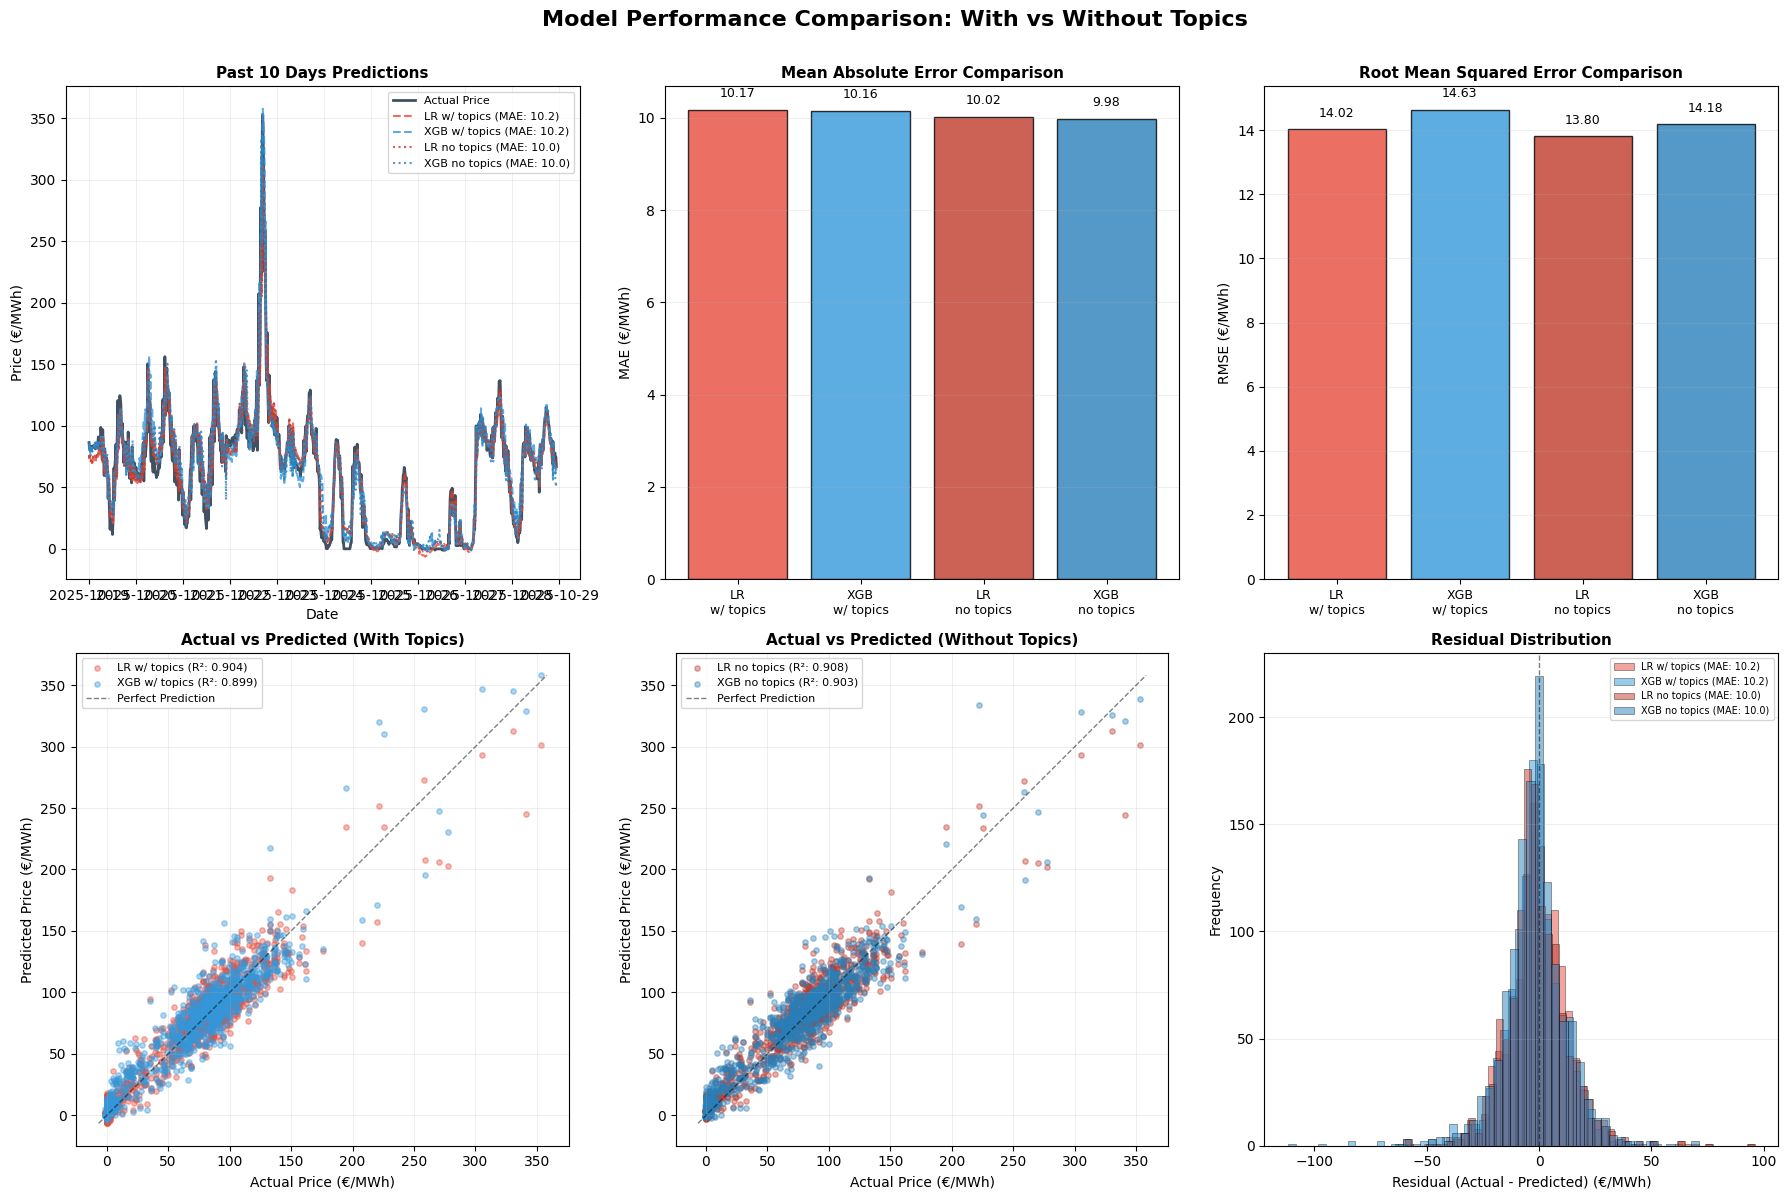

In [31]:
# Calculate metrics for display
lr_mae = mean_absolute_error(y_test, lr_predictions)
lr_rmse = np.sqrt(mean_squared_error(y_test, lr_predictions))
xgb_mae = mean_absolute_error(y_test, xgb_predictions)
xgb_rmse = np.sqrt(mean_squared_error(y_test, xgb_predictions))
lr_no_topics_mae = mean_absolute_error(y_test, lr_no_topics_predictions)
lr_no_topics_rmse = np.sqrt(mean_squared_error(y_test, lr_no_topics_predictions))
xgb_no_topics_mae = mean_absolute_error(y_test, xgb_no_topics_predictions)
xgb_no_topics_rmse = np.sqrt(mean_squared_error(y_test, xgb_no_topics_predictions))

# Create 2x3 subplot figure for 4 models
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
fig.suptitle('Model Performance Comparison: With vs Without Topics', fontsize=16, fontweight='bold', y=0.995)

# Subplot 1: Past 10 Days Predictions
ax1 = axes[0, 0]
num_days = 10
test_dates = test_df.index

if hasattr(test_dates, "normalize"):
    unique_dates = test_dates.normalize().unique()
    last_10_days = unique_dates[-num_days:]
    mask = test_dates.normalize().isin(last_10_days)
else:
    mask = np.arange(len(test_dates)) >= (len(test_dates) - num_days * 24)

test_dates_10 = test_dates[mask]
y_test_10 = y_test[mask]
lr_predictions_10 = lr_predictions[mask]
xgb_predictions_10 = xgb_predictions[mask]
lr_no_topics_predictions_10 = lr_no_topics_predictions[mask]
xgb_no_topics_predictions_10 = xgb_no_topics_predictions[mask]

ax1.plot(test_dates_10, y_test_10, label='Actual Price', linewidth=2, alpha=0.9, color='#2c3e50')
ax1.plot(test_dates_10, lr_predictions_10, label=f'LR w/ topics (MAE: {lr_mae:.1f})', linewidth=1.5, alpha=0.8, linestyle='--', color='#e74c3c')
ax1.plot(test_dates_10, xgb_predictions_10, label=f'XGB w/ topics (MAE: {xgb_mae:.1f})', linewidth=1.5, alpha=0.8, linestyle='--', color='#3498db')
ax1.plot(test_dates_10, lr_no_topics_predictions_10, label=f'LR no topics (MAE: {lr_no_topics_mae:.1f})', linewidth=1.5, alpha=0.8, linestyle=':', color='#c0392b')
ax1.plot(test_dates_10, xgb_no_topics_predictions_10, label=f'XGB no topics (MAE: {xgb_no_topics_mae:.1f})', linewidth=1.5, alpha=0.8, linestyle=':', color='#2980b9')
ax1.set_xlabel('Date', fontsize=10)
ax1.set_ylabel('Price (€/MWh)', fontsize=10)
ax1.set_title('Past 10 Days Predictions', fontsize=11, fontweight='bold')
ax1.legend(loc='best', frameon=True, fontsize=8)
ax1.grid(True, alpha=0.3, linestyle='-', linewidth=0.5)

# Subplot 2: Bar Chart of Model Accuracy (MAE)
ax2 = axes[0, 1]
bar_width = 0.2
models = ['LR\nw/ topics', 'XGB\nw/ topics', 'LR\nno topics', 'XGB\nno topics']
mae_scores = [lr_mae, xgb_mae, lr_no_topics_mae, xgb_no_topics_mae]
colors = ['#e74c3c', '#3498db', '#c0392b', '#2980b9']

x = np.arange(len(models))
bars = ax2.bar(x, mae_scores, bar_width * 4, color=colors, alpha=0.8, edgecolor='black')

for i, (bar, v) in enumerate(zip(bars, mae_scores)):
    ax2.text(bar.get_x() + bar.get_width()/2, v + 0.02 * max(mae_scores), f"{v:.2f}", 
             ha='center', va='bottom', fontsize=9)

ax2.set_xticks(x)
ax2.set_xticklabels(models, fontsize=9)
ax2.set_ylabel('MAE (€/MWh)', fontsize=10)
ax2.set_title('Mean Absolute Error Comparison', fontsize=11, fontweight='bold')
ax2.grid(True, axis='y', alpha=0.3, linestyle='-', linewidth=0.5)

# Subplot 3: Bar Chart of Model Accuracy (RMSE)
ax3 = axes[0, 2]
rmse_scores = [lr_rmse, xgb_rmse, lr_no_topics_rmse, xgb_no_topics_rmse]

bars = ax3.bar(x, rmse_scores, bar_width * 4, color=colors, alpha=0.8, edgecolor='black')

for i, (bar, v) in enumerate(zip(bars, rmse_scores)):
    ax3.text(bar.get_x() + bar.get_width()/2, v + 0.02 * max(rmse_scores), f"{v:.2f}", 
             ha='center', va='bottom', fontsize=9)

ax3.set_xticks(x)
ax3.set_xticklabels(models, fontsize=9)
ax3.set_ylabel('RMSE (€/MWh)', fontsize=10)
ax3.set_title('Root Mean Squared Error Comparison', fontsize=11, fontweight='bold')
ax3.grid(True, axis='y', alpha=0.3, linestyle='-', linewidth=0.5)

# Subplot 4: Scatter Plot - Actual vs Predicted (With Topics)
ax4 = axes[1, 0]
min_price = min(y_test.min(), lr_predictions.min(), xgb_predictions.min(), 
                lr_no_topics_predictions.min(), xgb_no_topics_predictions.min())
max_price = max(y_test.max(), lr_predictions.max(), xgb_predictions.max(), 
                lr_no_topics_predictions.max(), xgb_no_topics_predictions.max())

ax4.scatter(y_test, lr_predictions, alpha=0.4, s=15, color='#e74c3c', 
            label=f'LR w/ topics (R²: {np.corrcoef(y_test, lr_predictions)[0,1]**2:.3f})')
ax4.scatter(y_test, xgb_predictions, alpha=0.4, s=15, color='#3498db', 
            label=f'XGB w/ topics (R²: {np.corrcoef(y_test, xgb_predictions)[0,1]**2:.3f})')
ax4.plot([min_price, max_price], [min_price, max_price], 'k--', linewidth=1, alpha=0.5, label='Perfect Prediction')
ax4.set_xlabel('Actual Price (€/MWh)', fontsize=10)
ax4.set_ylabel('Predicted Price (€/MWh)', fontsize=10)
ax4.set_title('Actual vs Predicted (With Topics)', fontsize=11, fontweight='bold')
ax4.legend(loc='upper left', frameon=True, fontsize=8)
ax4.grid(True, alpha=0.3, linestyle='-', linewidth=0.5)
ax4.set_aspect('equal', adjustable='box')

# Subplot 5: Scatter Plot - Actual vs Predicted (Without Topics)
ax5 = axes[1, 1]
ax5.scatter(y_test, lr_no_topics_predictions, alpha=0.4, s=15, color='#c0392b', 
            label=f'LR no topics (R²: {np.corrcoef(y_test, lr_no_topics_predictions)[0,1]**2:.3f})')
ax5.scatter(y_test, xgb_no_topics_predictions, alpha=0.4, s=15, color='#2980b9', 
            label=f'XGB no topics (R²: {np.corrcoef(y_test, xgb_no_topics_predictions)[0,1]**2:.3f})')
ax5.plot([min_price, max_price], [min_price, max_price], 'k--', linewidth=1, alpha=0.5, label='Perfect Prediction')
ax5.set_xlabel('Actual Price (€/MWh)', fontsize=10)
ax5.set_ylabel('Predicted Price (€/MWh)', fontsize=10)
ax5.set_title('Actual vs Predicted (Without Topics)', fontsize=11, fontweight='bold')
ax5.legend(loc='upper left', frameon=True, fontsize=8)
ax5.grid(True, alpha=0.3, linestyle='-', linewidth=0.5)
ax5.set_aspect('equal', adjustable='box')

# Subplot 6: Residuals Distribution
ax6 = axes[1, 2]
lr_residuals = y_test - lr_predictions
xgb_residuals = y_test - xgb_predictions
lr_no_topics_residuals = y_test - lr_no_topics_predictions
xgb_no_topics_residuals = y_test - xgb_no_topics_predictions

ax6.hist(lr_residuals, bins=50, alpha=0.5, color='#e74c3c', label=f'LR w/ topics (MAE: {lr_mae:.1f})', edgecolor='black', linewidth=0.5)
ax6.hist(xgb_residuals, bins=50, alpha=0.5, color='#3498db', label=f'XGB w/ topics (MAE: {xgb_mae:.1f})', edgecolor='black', linewidth=0.5)
ax6.hist(lr_no_topics_residuals, bins=50, alpha=0.5, color='#c0392b', label=f'LR no topics (MAE: {lr_no_topics_mae:.1f})', edgecolor='black', linewidth=0.5)
ax6.hist(xgb_no_topics_residuals, bins=50, alpha=0.5, color='#2980b9', label=f'XGB no topics (MAE: {xgb_no_topics_mae:.1f})', edgecolor='black', linewidth=0.5)
ax6.axvline(0, color='black', linestyle='--', linewidth=1, alpha=0.5)
ax6.set_xlabel('Residual (Actual - Predicted) (€/MWh)', fontsize=10)
ax6.set_ylabel('Frequency', fontsize=10)
ax6.set_title('Residual Distribution', fontsize=11, fontweight='bold')
ax6.legend(loc='best', frameon=True, fontsize=7)
ax6.grid(True, alpha=0.3, linestyle='-', linewidth=0.5, axis='y')

plt.tight_layout(rect=[0, 0, 1, 0.99])
plt.show()